In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# pip install packages
! pip install xarray dask h5netcdf cfgrib --quiet

In [ ]:
# import all required packages
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import seaborn as sns
import pandas as pd

In [ ]:
# read csv
temp_df = pd.read_csv('/content/drive/MyDrive/reanalysis-era5-single-levels-timeseries-sfchwf9l4_0.csv')
temp_df.head()

,valid_time,t2m,latitude,longitude
0,2000-01-01 00:00:00,285.35065,-0.5,37.0
1,2000-01-01 01:00:00,285.79034,-0.5,37.0
2,2000-01-01 02:00:00,285.65747,-0.5,37.0
3,2000-01-01 03:00:00,286.12180,-0.5,37.0
4,2000-01-01 04:00:00,285.60565,-0.5,37.0


In [ ]:
# DROP LAT ND LONG COLUMN
temp_df = temp_df.drop(['latitude', 'longitude'], axis=1)
temp_df.head()

,valid_time,t2m
0,2000-01-01 00:00:00,285.35065
1,2000-01-01 01:00:00,285.79034
2,2000-01-01 02:00:00,285.65747
3,2000-01-01 03:00:00,286.12180
4,2000-01-01 04:00:00,285.60565


In [ ]:
# CONVERT temp to degrees
temp_df['t2m'] = temp_df['t2m'] - 273.15
temp_df.head()

,valid_time,t2m
0,2000-01-01 00:00:00,12.20065
1,2000-01-01 01:00:00,12.64034
2,2000-01-01 02:00:00,12.50747
3,2000-01-01 03:00:00,12.97180
4,2000-01-01 04:00:00,12.45565


In [ ]:
# summary statistics
temp_df.describe()

,t2m
count,229752.000000
mean,15.584902
std,3.294037
min,4.292020
25%,13.167020
50%,15.044610
75%,17.940308
max,27.534140


In [ ]:
# info
temp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229752 entries, 0 to 229751
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   valid_time  229752 non-null  object 
 1   t2m         229752 non-null  float64
dtypes: float64(1), object(1)
memory usage: 3.5+ MB


In [ ]:
# convert valid time to datetime objext
temp_df['valid_time'] = pd.to_datetime(temp_df['valid_time'])
temp_df.head()

,valid_time,t2m
0,2000-01-01 00:00:00,12.20065
1,2000-01-01 01:00:00,12.64034
2,2000-01-01 02:00:00,12.50747
3,2000-01-01 03:00:00,12.97180
4,2000-01-01 04:00:00,12.45565


In [ ]:
# info
temp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229752 entries, 0 to 229751
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   valid_time  229752 non-null  datetime64[ns]
 1   t2m         229752 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.5 MB


In [ ]:
# set valid time as index
temp_df = temp_df.set_index('valid_time')
temp_df.head()

,t2m
valid_time,
2000-01-01 00:00:00,12.20065
2000-01-01 01:00:00,12.64034
2000-01-01 02:00:00,12.50747
2000-01-01 03:00:00,12.97180
2000-01-01 04:00:00,12.45565


<Axes: xlabel='valid_time'>

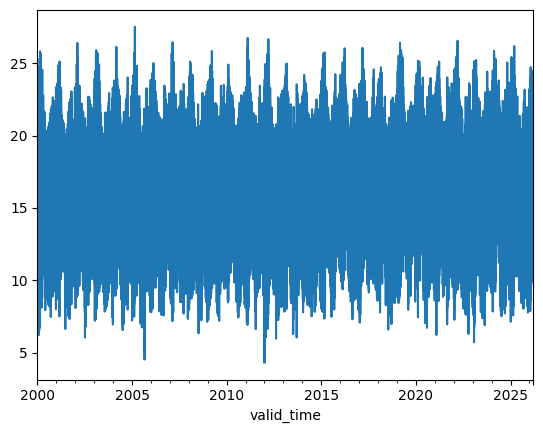

In [ ]:
# plot timeseries
temp_df['t2m'].plot()

In [ ]:
# resample to monthly
temp_df_monthly = temp_df.resample('MS').mean()

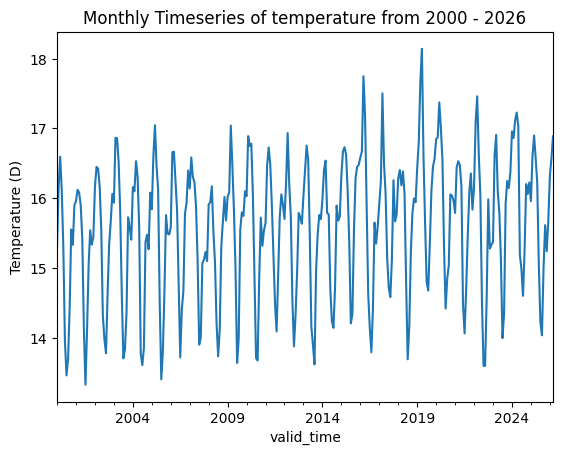

In [ ]:
# plot montly ts
temp_df_monthly['t2m'].plot()
plt.title('Monthly Timeseries of temperature from 2000 - 2026')
plt.ylabel('Temperature (D)')
plt.show()
#

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [ ]:
# check stationarity
result = adfuller(temp_df_monthly['t2m'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -3.816263
p-value: 0.002745


In [ ]:
# decompose data
decomposed = seasonal_decompose(temp_df_monthly['t2m'], model='additive', period=12)

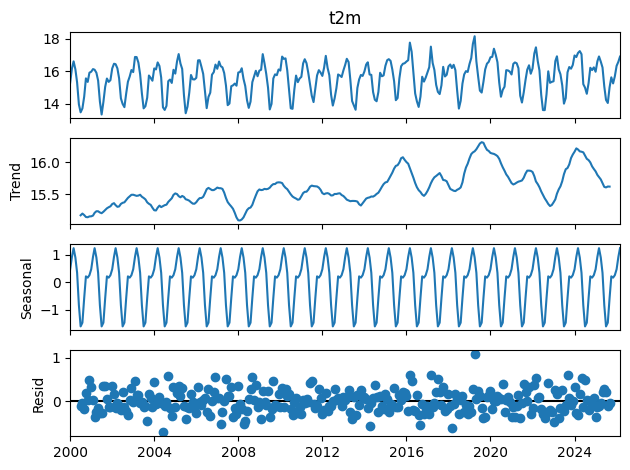

In [ ]:
decomposed.plot()
plt.show()

In [ ]:
! pip install pmdarima --quiet

In [ ]:
# fit model
import pmdarima as pm

# Split: Train on 2000-2024, Test on 2025-2026
train = temp_df_monthly.loc[:'2024-12-31']
test = temp_df_monthly.loc['2025-01-01':]

stepwise_model = pm.auto_arima(train['t2m'],
                              start_p=1, start_q=1,
                              max_p=3, max_q=3,
                              m=12,           # Seasonal period (12 months)
                              start_P=0,
                              seasonal=True,
                              d=1, D=1,
                              trace=True,
                              error_action='ignore',
                              suppress_warnings=True,
                              stepwise=True)

print(stepwise_model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=1.88 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=437.177, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=325.997, Time=0.30 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=1.40 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=397.495, Time=0.08 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=265.367, Time=0.85 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=2.86 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=5.19 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=309.022, Time=0.67 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=248.523, Time=1.21 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=307.545, Time=0.44 sec
 ARIMA(2,1,0)(2,1,1)[12]             : AIC=inf, Time=3.58 sec
 ARIMA(2,1,0)(1,1,1)[12]             : AIC=inf, Time=3.28 sec
 ARIMA(3,1,0)(2,1,0)[12]             : AIC=242.717, Time=2.42 sec
 ARIMA(3,1,0)(1,1,0)[12]             : AIC=297.437, Time=

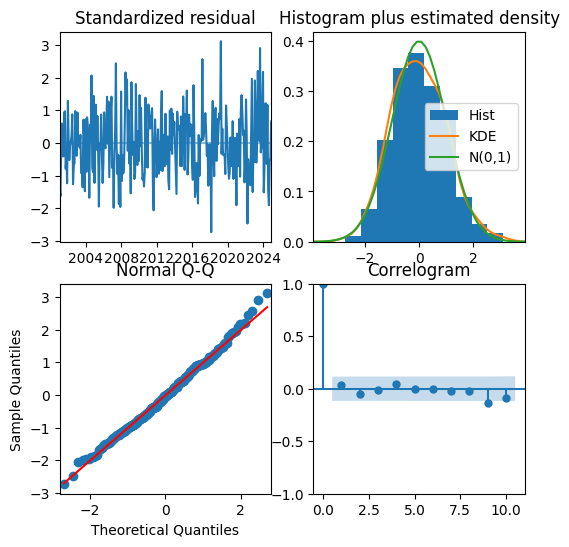

In [ ]:
# plot diagnostic
stepwise_model.plot_diagnostics(figsize=(6, 6))
plt.show()

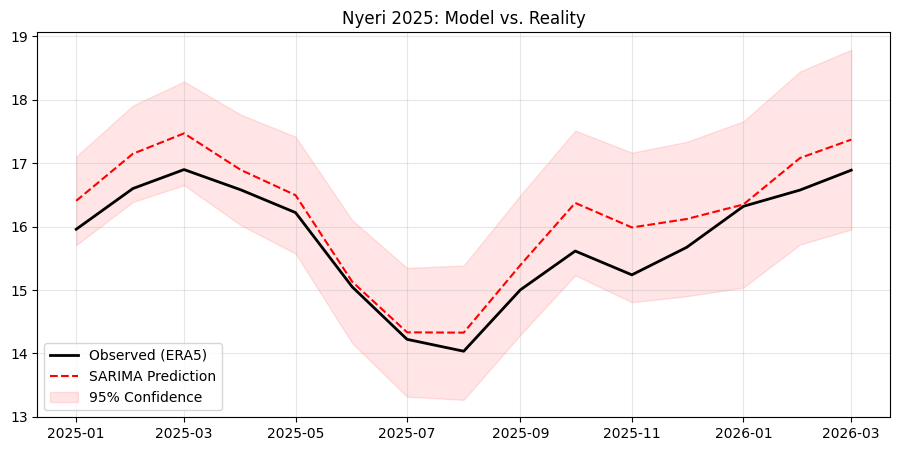

In [ ]:
forecast, conf_int = stepwise_model.predict(n_periods=len(test), return_conf_int=True)

plt.figure(figsize=(11, 5))
plt.plot(test.index, test['t2m'], label='Observed (ERA5)', color='black', lw=2)
plt.plot(test.index, forecast, label='SARIMA Prediction', color='red', linestyle='--')
plt.fill_between(test.index, conf_int[:, 0], conf_int[:, 1], color='red', alpha=0.1, label='95% Confidence')
plt.title("Nyeri 2025: Model vs. Reality")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

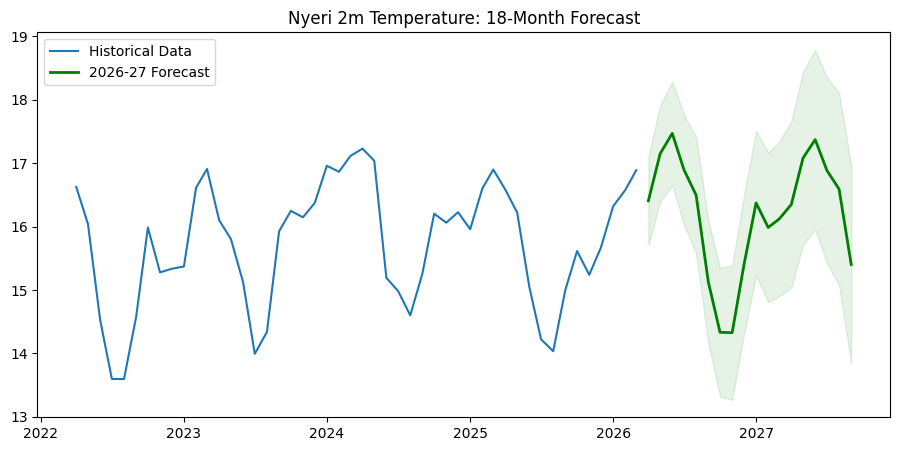

In [ ]:
# Forecast 18 months into the future
future_fc, future_conf = stepwise_model.predict(n_periods=18, return_conf_int=True)
future_dates = pd.date_range(temp_df_monthly.index[-1], periods=19, freq='MS')[1:]

plt.figure(figsize=(11, 5))
plt.plot(temp_df_monthly.index[-48:], temp_df_monthly['t2m'][-48:], label='Historical Data')
plt.plot(future_dates, future_fc, label='2026-27 Forecast', color='green', lw=2)
plt.fill_between(future_dates, future_conf[:, 0], future_conf[:, 1], color='green', alpha=0.1)
plt.title("Nyeri 2m Temperature: 18-Month Forecast")
plt.legend()
plt.show()